<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
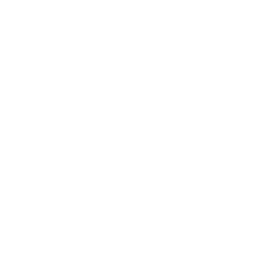
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análisis de Similitud de Planes de Estudio</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Educación Superior / Diseño de Programas Académicos &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este cuaderno mide el solapamiento de planes de estudio en un catálogo
universitario de cursos usando **PROC DISTANCE** con **METHOD=DJACCARD**
— el coeficiente de *disimilitud* de Jaccard, la distancia natural para
datos binarios de presencia/ausencia. Cada curso lleva 40 indicadores
binarios que marcan qué resultados de aprendizaje de acreditación cubre,
de modo que la distancia de Jaccard entre dos cursos es la proporción de
resultados cubiertos que **no** tienen en común (0 = conjuntos de
resultados idénticos, 1 = ningún resultado compartido).

El análisis se desarrolla en dos partes. Primero, sobre un catálogo de
100 cursos, perfila la amplitud de cobertura de resultados por
departamento (PROC MEANS, PROC FREQ, un diagrama de caja de cobertura) y
señala los resultados de aprendizaje que **ningún** curso de un
departamento cubre (brechas de cobertura). Segundo, profundiza en un
panel focalizado de 10 cursos extraído de los dos departamentos con
mayor solapamiento cuantitativo — Estadística y Ciencia de Datos —,
calcula la matriz completa de distancias de Jaccard por pares y clasifica
los pares de cursos más cercanos como candidatos para revisión de
consolidación. El objetivo es dar a un comité de plan de estudios dos
artefactos concretos: una lista clasificada de los cursos más similares y
un mapa de brechas por departamento y resultado.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Cobertura binaria de resultados de aprendizaje por curso (40 indicadores de resultados) | 100 |
| WORK.PANEL10 | Panel de consolidación de Estadística + Ciencia de Datos | 10 |

El catálogo es sintético. Los indicadores de resultados se extraen con
probabilidades específicas de cada departamento para que las disciplinas
enfaticen distintas agrupaciones de resultados (informática y matemáticas
ponderan los primeros resultados, las ciencias de laboratorio ponderan la
banda intermedia), dando al análisis de distancia una estructura
realista. Este entorno se ejecuta sin licencia, por lo que el catálogo de
trabajo está limitado a 100 cursos.

---

In [1]:
/* --------------------------------------------------------
   Genera una matriz sintética de resultados de aprendizaje
   500 cursos x 40 resultados de aprendizaje de acreditación
   (el modo sin licencia conserva los primeros 100)
   -------------------------------------------------------- */
DATOS work.course_outcomes;
    LLAMAR streaminit(42);
    ARREGLO outcomes[40] lo_1 - lo_40;
    ARREGLO dept_list[8] $15 _temporary_ ('INFORMATICA' 'MATEMATICAS' 'ESTADISTICA' 'INGENIERIA' 'BIOLOGIA' 'QUIMICA' 'FISICA' 'CIENCIA_DATOS');
    HACER course_id = 1 HASTA 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* El nivel del curso afecta a la amplitud de resultados */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Agrupaciones de resultados propias de cada departamento */
        HACER lo = 1 HASTA 40;
            base_prob = 0.15;
            /* Dept 1-2 (Informatica, Matematicas): enfatizan resultados 1-15 */
            SI dept_idx <= 2 AND lo <= 15 ENTONCES
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Estadistica, Ingenieria): enfatizan resultados 10-25 */
            SINO SI dept_idx IN (3, 4) AND 10 <= lo <= 25 ENTONCES
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Biologia, Quimica, Fisica): enfatizan 20-35 */
            SINO SI dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 ENTONCES
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Ciencia de Datos): cobertura amplia */
            SINO SI dept_idx = 8 ENTONCES
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        END;
        SALIDA;
    END;
    ELIMINAR dept_idx course_level base_prob lo;
EJECUTAR;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.92 seconds
  cpu   1.92 seconds


In [2]:
/* --------------------------------------------------------
   Genera los metadatos del catálogo de cursos
   -------------------------------------------------------- */
DATOS work.course_catalog;
    LLAMAR streaminit(43);
    ARREGLO dept_list[8] $15 _temporary_ ('INFORMATICA' 'MATEMATICAS' 'ESTADISTICA' 'INGENIERIA' 'BIOLOGIA' 'QUIMICA' 'FISICA' 'CIENCIA_DATOS');
    ARREGLO format_list[3] $12 _temporary_ ('MAGISTRAL' 'LABORATORIO' 'SEMINARIO');
    HACER course_id = 1 HASTA 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        SALIDA;
    END;
    ELIMINAR dept_idx format_idx;
    FORMATO last_offered date9.;
EJECUTAR;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                             Cobertura media de resultados de aprendizaje por departamento                              

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                             N
                                          Departamento     Obs           Mean
                                          -----------------------------------
                                          BIOLOGIA          10      0.2000000
                                          CIENCIA_DATOS     14      0.1428571
                                          ESTADISTICA       11      0.0909091
                                          FISICA             7      0.2857143
                                          INFORMATICA       13      0.3846154
                                          INGENIERIA        17      0.0000000
                                          MATEM


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


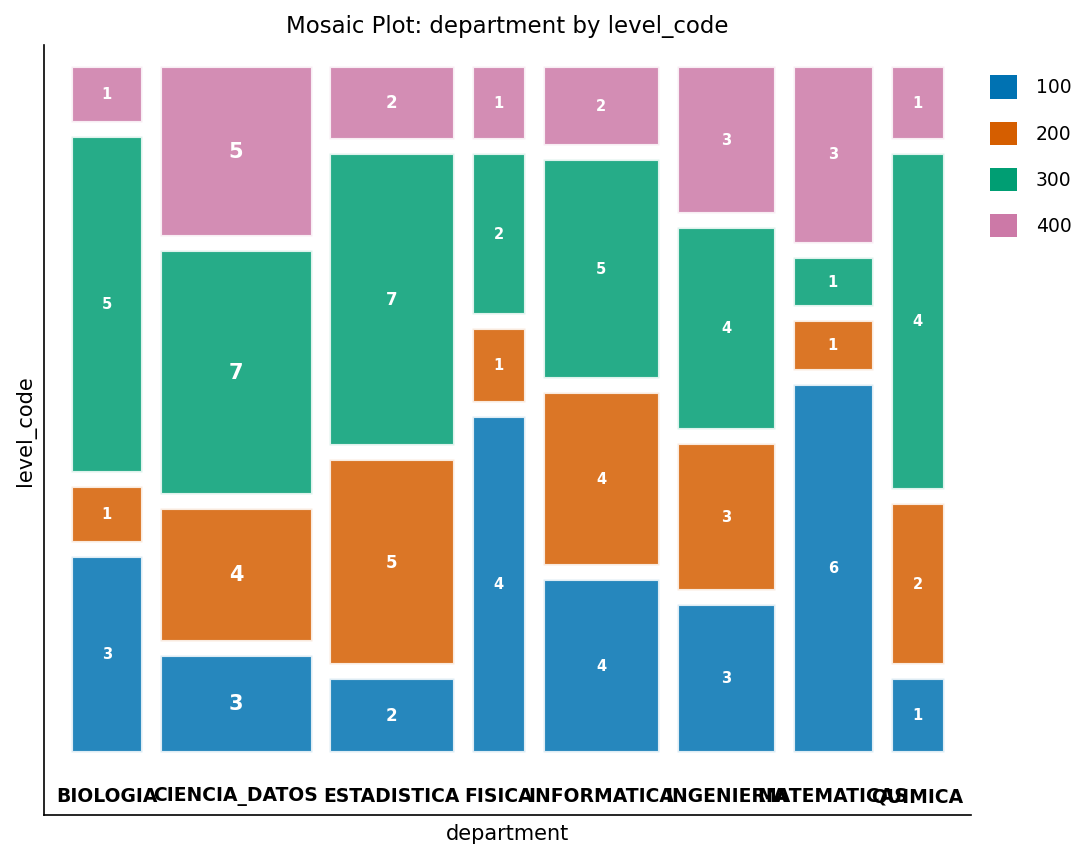

In [3]:
/* --------------------------------------------------------
   Cobertura basal de resultados de aprendizaje por departamento
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.course_outcomes mean;
    CLASE department;
    VAR lo_1 - lo_40;
    ETIQUETA department='Departamento';
    TÍTULO 'Cobertura media de resultados de aprendizaje por departamento';
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    ETIQUETA department='Departamento' level_code='Nivel';
    TÍTULO 'Cursos por departamento y nivel';
EJECUTAR;

---

                                            Cursos por departamento y nivel                                             




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


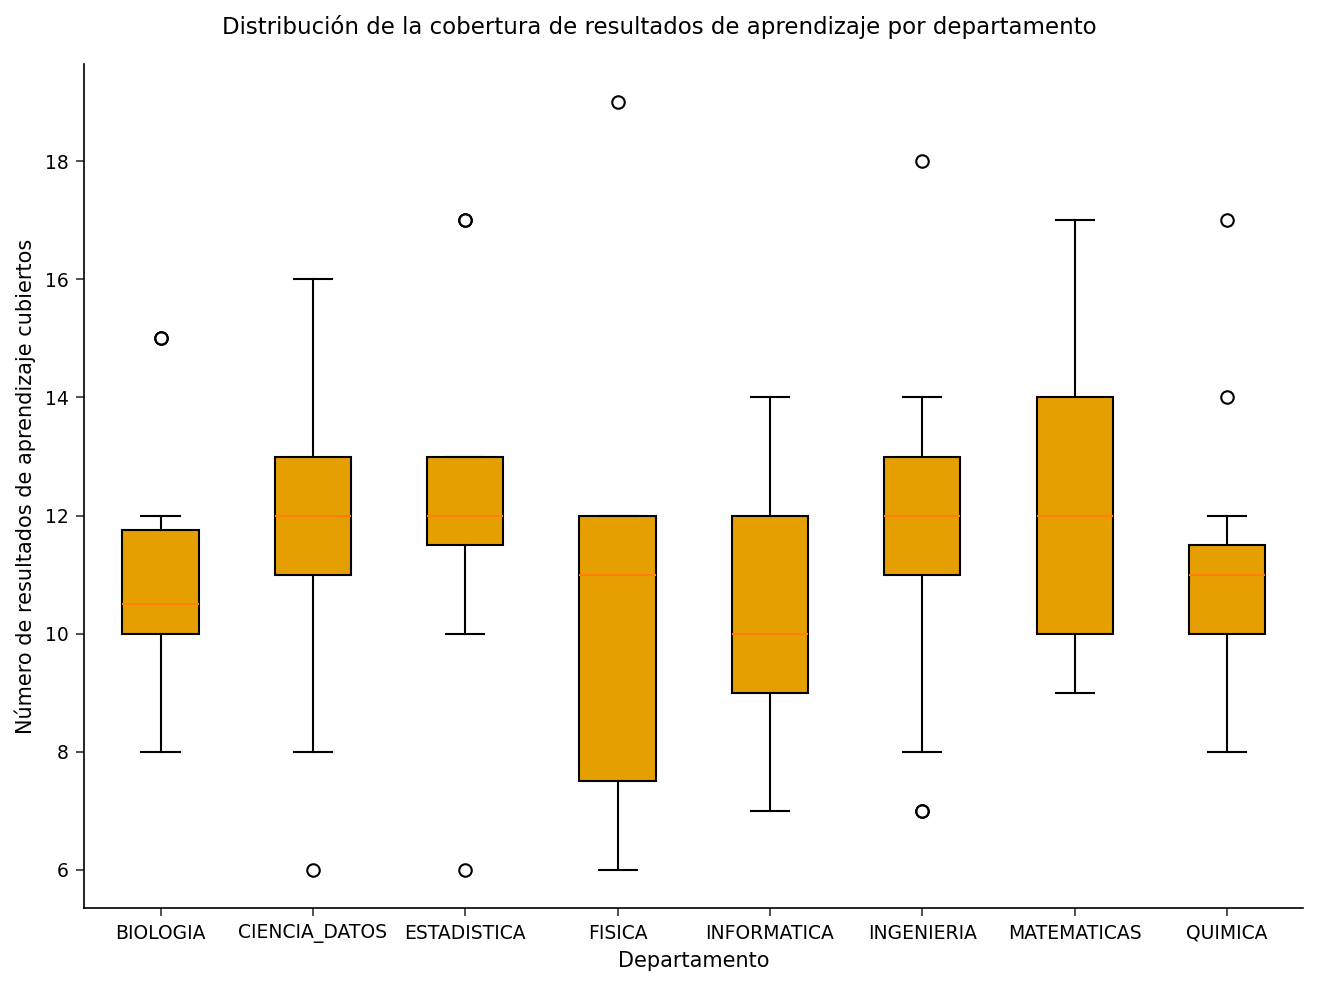

In [4]:
/* --------------------------------------------------------
   Densidad de cobertura de resultados por departamento
   -------------------------------------------------------- */
DATOS work.outcome_counts;
    ESTABLECER work.course_outcomes;
    ARREGLO outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS ETIQUETA='Número de resultados de aprendizaje cubiertos';
    XAXIS ETIQUETA='Departamento';
    TÍTULO 'Distribución de la cobertura de resultados de aprendizaje por departamento';
EJECUTAR;

---

In [5]:
/* --------------------------------------------------------
   Panel de consolidación: los primeros 10 cursos de
   Estadística / Ciencia de Datos (los dos departamentos con
   mayor solapamiento cuantitativo). Se reetiquetan como
   P01-P10 con un contador secuencial para que la matriz
   cuadrada de distancias OUT= tenga columnas limpias y
   direccionables; luego se calcula la matriz completa de
   distancias de Jaccard por pares con METHOD=DJACCARD
   (0 = conjuntos de resultados idénticos, 1 = ningún
   resultado compartido).
   -------------------------------------------------------- */
DATOS work.panel10;
    ESTABLECER work.course_outcomes(DONDE=(department IN ('ESTADISTICA' 'CIENCIA_DATOS')));
    RETENER seq 0;
    seq + 1;
    SI seq > 10 ENTONCES PARAR;
    panel_id = cat('P', PUT(seq, z2.));
    ELIMINAR seq;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.panel10 noobs ETIQUETA;
    VAR panel_id course_label department level_code;
    ETIQUETA panel_id = 'ID del panel' course_label = 'Curso'
          department = 'Departamento' level_code = 'Nivel';
    TÍTULO 'Panel de consolidación: cursos de Estadística y Ciencia de Datos';
EJECUTAR;

PROCEDIMIENTO distance DATOS=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VAR nominal(lo_1 - lo_40);
    id panel_id;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.panel_dist noobs;
    TÍTULO 'Matriz de distancias de Jaccard por pares (10 cursos)';
EJECUTAR;

                            Panel de consolidación: cursos de Estadística y Ciencia de Datos                            

ID del panel    Curso   Departamento  Nivel
P01           CRS0003  CIENCIA_DATOS    300
P02           CRS0006  ESTADISTICA      300
P03           CRS0014  CIENCIA_DATOS    300
P04           CRS0015  ESTADISTICA      300
P05           CRS0017  ESTADISTICA      200
P06           CRS0019  CIENCIA_DATOS    100
P07           CRS0022  ESTADISTICA      400
P08           CRS0033  CIENCIA_DATOS    200
P09           CRS0038  ESTADISTICA      100
P10           CRS0040  ESTADISTICA      100

                            Panel de consolidación: cursos de Estadística y Ciencia de Datos                            

                                 Matriz de distancias de Jaccard por pares (10 cursos)                                  

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P0


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reorganiza la matriz cuadrada de distancias en una lista
   ordenada de pares de cursos. Las columnas de distancia
   OUT= se direccionan con una lista explícita de nombres
   (P01 P02 ... P10); solo se conserva el triángulo superior
   estricto (col > row), de modo que cada par no ordenado
   aparece una vez y se omite la diagonal de ceros. Los cinco
   pares más cercanos son los candidatos a revisión de
   consolidación.
   -------------------------------------------------------- */
DATOS work.similar_courses;
    ESTABLECER work.panel_dist;
    ARREGLO d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LONGITUD course_a course_b $8;
    course_a = _name_;
    row + 1;
    HACER col = 1 HASTA 10;
        SI col > row ENTONCES HACER;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            SALIDA;
        END;
    END;
    MANTENER course_a course_b jaccard_dist;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VAR jaccard_dist;
    ETIQUETA jaccard_dist='Distancia de Jaccard';
    TÍTULO 'Distribución de las distancias de Jaccard por pares (45 pares de cursos)';
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=work.similar_courses; POR jaccard_dist; EJECUTAR;

DATOS work.top_pairs;
    ESTABLECER work.similar_courses;
    pair_rank = _n_;
    SI pair_rank <= 5;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.top_pairs noobs ETIQUETA;
    VAR pair_rank course_a course_b jaccard_dist;
    ETIQUETA pair_rank = 'Rango' course_a = 'Curso A'
          course_b = 'Curso B' jaccard_dist = 'Distancia de Jaccard';
    TÍTULO 'Cinco pares de cursos más cercanos (candidatos a consolidación)';
EJECUTAR;

                        Distribución de las distancias de Jaccard por pares (45 pares de cursos)                        

                                                  The MEANS Procedure

 Variable      Label                       N     Minimum   Lower Quartile      Median        Mean     Maximum
 ------------------------------------------------------------------------------------------------------------
 jaccard_dist  Distancia de Jaccard       45       0.588            0.762       0.826       0.818       0.962
 ------------------------------------------------------------------------------------------------------------

                            Cinco pares de cursos más cercanos (candidatos a consolidación)                             

Rango  Curso A  Curso B  Distancia de Jaccard
    1  P02      P10                     0.588
    2  P03      P04                       0.6
    3  P03      P05                     0.667
    4  P02      P04                     0.684
    5  P02    


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                Resultados de aprendizaje no cubiertos por departamento                                 

                                                   The FREQ Procedure

Departamento    Frequency    Percent
-------------------------------------
BIOLOGIA                8     26.67
ESTADISTICA             3     10.00
FISICA                  8     26.67
INFORMATICA             3     10.00
INGENIERIA              2      6.67
MATEMATICAS             4     13.33
QUIMICA                 2      6.67
                                  Muestra de brechas de resultados (primeras 12 de 30)                                  

Departamento  Resultado no cubierto
BIOLOGIA      LO02
BIOLOGIA      LO10
BIOLOGIA      LO15
BIOLOGIA      LO16
BIOLOGIA      LO17
BIOLOGIA      LO18
BIOLOGIA      LO36
BIOLOGIA      LO37
ESTADISTICA   LO09
ESTADISTICA   LO35
ESTADISTICA   LO37
FISICA        LO02

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


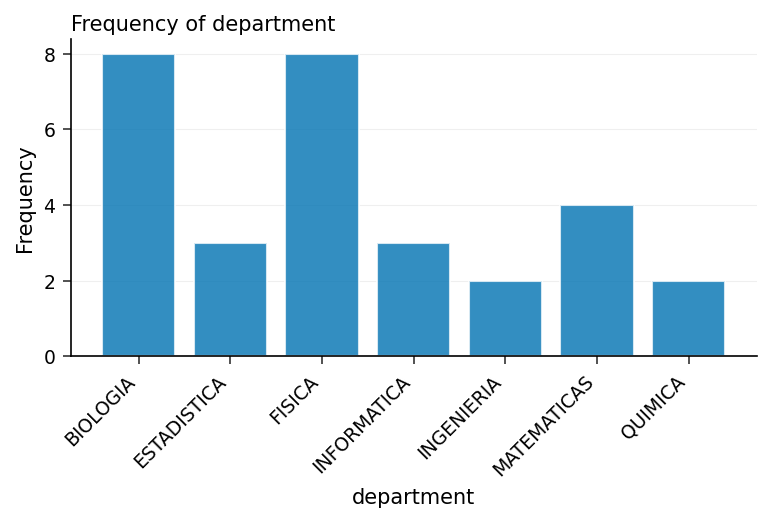

In [7]:
/* --------------------------------------------------------
   Brechas de resultados: resultados de aprendizaje que
   NINGÚN curso de un departamento cubre. PROC MEANS suma
   cada indicador binario de resultado dentro del
   departamento; una suma de cero significa que el resultado
   está ausente del catálogo de ese departamento.
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.course_outcomes sum NOPRINT;
    CLASE department;
    VAR lo_1 - lo_40;
    SALIDA out=work.dept_coverage(DONDE=(_type_=1))
        sum=lo_1 - lo_40;
EJECUTAR;

DATOS work.outcome_gaps;
    ESTABLECER work.dept_coverage;
    ARREGLO outcomes[40] lo_1 - lo_40;
    HACER lo = 1 HASTA 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        SI courses_covering = 0 ENTONCES HACER;
            gap_flag = 1;
            SALIDA;
        END;
    END;
    MANTENER department outcome_id courses_covering gap_flag;
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.outcome_gaps;
    TABLES department / nocum;
    ETIQUETA department='Departamento';
    TÍTULO 'Resultados de aprendizaje no cubiertos por departamento';
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.outcome_gaps(obs=12) noobs ETIQUETA;
    VAR department outcome_id;
    ETIQUETA department = 'Departamento' outcome_id = 'Resultado no cubierto';
    TÍTULO 'Muestra de brechas de resultados (primeras 12 de 30)';
EJECUTAR;

---

### Interpretación

**Panel de consolidación.** A lo largo de los 45 pares no ordenados en el
panel de 10 cursos de Estadística / Ciencia de Datos, la distancia de
Jaccard va de 0.588 a 0.962 con una mediana de 0.826 (media 0.818). El
par más cercano es P02 y P10 a una distancia de 0.588, seguido de
P03–P04 a 0.600 y P03–P05 a 0.667. Incluso los cursos más
similares todavía difieren en aproximadamente el 59% de sus resultados
cubiertos, por lo que este catálogo no contiene **cursos casi
duplicados** — no hay ningún par que un comité pudiera fusionar sin más.
La lista clasificada apunta en cambio al puñado de pares que merecen una
comparación manual de programas antes del próximo ciclo del catálogo; los
pares de mayor distancia (cerca de 0.962) confirman que los cursos de
Estadística y Ciencia de Datos, pese a compartir vecindad de
departamento, abarcan conjuntos de resultados genuinamente distintos.

**Brechas de resultados.** Surgen treinta brechas por departamento y
resultado en todo el catálogo. Las disciplinas con mayor carga de
laboratorio acumulan la mayoría: **Biología** y **Física** dejan cada una
8 de los 40 resultados de acreditación sin cubrir, seguidas de
**Matemáticas** (4). Los departamentos cuantitativos son los mejor
cubiertos — **Química** e **Ingeniería** omiten solo 2 resultados cada
uno. Estas brechas son los objetivos naturales para el desarrollo de
nuevos cursos o la oferta compartida entre departamentos: un resultado
ausente de todo un departamento es un riesgo de cobertura en la
renovación de la acreditación, mientras que la lista de consolidación
aborda el problema opuesto del esfuerzo redundante. Juntos, los dos
artefactos permiten al comité ajustar el catálogo desde ambos extremos —
recortando el solapamiento y llenando los desiertos — usando una sola
medida de distancia basada en conjuntos.

---

In [8]:
/* --------------------------------------------------------
   Exporta los candidatos de consolidación ordenados y el
   mapa de brechas de resultados por departamento para el
   comité de plan de estudios.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>